In [ ]:
from numba import cuda
import numpy as np

@cuda.jit
def matmul_2d(A, B, C):
    # Global row and column
    row = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    col = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    # Check bounds
    if row < C.shape[0] and col < C.shape[1]:
        temp = 0.0
        for k in range(A.shape[1]):
            temp += A[row, k] * B[k, col]
        C[row, col] = temp


In [ ]:
M, K, N = 4, 3, 5

A = np.random.rand(M, K).astype(np.float32)
B = np.random.rand(K, N).astype(np.float32)
C = np.zeros((M, N), dtype=np.float32)


In [ ]:
d_A = cuda.to_device(A)
d_B = cuda.to_device(B)
d_C = cuda.to_device(C)


In [ ]:
threads_per_block = (16, 16)

blocks_per_grid_x = (N + threads_per_block[0] - 1) // threads_per_block[0]
blocks_per_grid_y = (M + threads_per_block[1] - 1) // threads_per_block[1]

blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)


In [ ]:
matmul_2d[blocks_per_grid, threads_per_block](d_A, d_B, d_C)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


In [ ]:
C = d_C.copy_to_host()

print("Matrix A:\n", A)
print("Matrix B:\n", B)
print("Matrix C = A x B:\n", C)


Matrix A:
 [[0.5259653  0.8956204  0.7957479 ]
 [0.65585846 0.2610976  0.35645932]
 [0.45664984 0.43301323 0.7733074 ]
 [0.32504573 0.12558906 0.57478356]]
Matrix B:
 [[0.43875012 0.1574042  0.13247311 0.7035236  0.50905704]
 [0.17113882 0.780277   0.7296751  0.57215524 0.46694425]
 [0.00237093 0.1578071  0.6782411  0.26513997 0.58350265]]
Matrix C = A x B:
 [[0.3859294  0.90719587 1.2628971  1.0934474  1.1502721 ]
 [0.33328703 0.36321515 0.5191654  0.7053119  0.66378236]
 [0.276294   0.53178227 0.9009416  0.7740494  0.88588077]
 [0.1654698  0.23986274 0.52454084 0.45293188 0.55949765]]


In [ ]:
print("NumPy Result:\n", A @ B)


NumPy Result:
 [[0.3859294  0.9071958  1.262897   1.0934474  1.1502721 ]
 [0.33328703 0.36321515 0.5191654  0.7053119  0.66378236]
 [0.27629402 0.53178227 0.9009416  0.7740494  0.88588077]
 [0.1654698  0.23986275 0.52454084 0.45293188 0.55949765]]


## Convert RGB to greyscale

In [ ]:
from numba import cuda
import numpy as np
import time

start = time.time()
@cuda.jit
def rgb_to_grayscale(rgb_img, gray_img):
    row = cuda.blockIdx.y * cuda.blockDim.y + cuda.threadIdx.y
    col = cuda.blockIdx.x * cuda.blockDim.x + cuda.threadIdx.x

    if row < rgb_img.shape[0] and col < rgb_img.shape[1]:
        r = rgb_img[row, col, 0]
        g = rgb_img[row, col, 1]
        b = rgb_img[row, col, 2]

        gray_img[row, col] = 0.299 * r + 0.587 * g + 0.114 * b


(np.float64(-0.5), np.float64(539.5), np.float64(249.5), np.float64(-0.5))

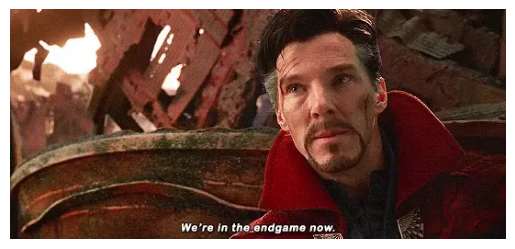

In [ ]:
img_path = "/content/Endgane_image.jpg"

import cv2
import matplotlib.pyplot as plt
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis("off")


In [ ]:


# Output grayscale image
gray = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)


In [ ]:
d_image = cuda.to_device(image)
d_gray = cuda.to_device(gray)
threads_per_block = (16, 16)

blocks_per_grid_x = (image.shape[1] + threads_per_block[0] - 1) // threads_per_block[0]
blocks_per_grid_y = (image.shape[0] + threads_per_block[1] - 1) // threads_per_block[1]

blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)
rgb_to_grayscale[blocks_per_grid, threads_per_block](d_image, d_gray)
gray = d_gray.copy_to_host()
print(gray.shape)


(250, 540)


In [ ]:
gray = d_gray.copy_to_host()
print(gray.shape)


(250, 540)


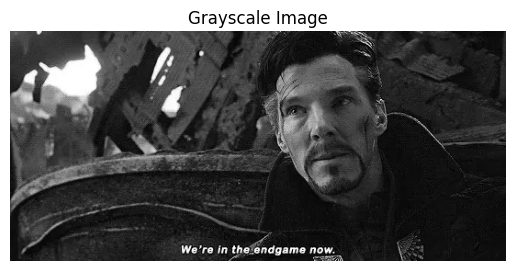

In [ ]:
import matplotlib.pyplot as plt


plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.show()


In [ ]:
end = time.time()
print("Execution time:", end - start, "seconds")